<a href="https://colab.research.google.com/github/rehansolo15/foodInsecurityamongstSEC/blob/main/rehansaraiya-trubrudgeProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [56]:
df = pd.read_csv("/content/Obesity_DataSet_2.csv")
df
df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7481 entries, 0 to 7480
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   BMI_WHO          7384 non-null   object 
 1   Age              7481 non-null   int64  
 2   Gender           7481 non-null   object 
 3   Race1            7481 non-null   object 
 4   Education        7221 non-null   object 
 5   HHIncome         6838 non-null   object 
 6   PhysActive       7481 non-null   object 
 7   Smoke100         7235 non-null   object 
 8   Diabetes         7479 non-null   object 
 9   BPSysAve         7205 non-null   float64
 10  TotChol          7076 non-null   float64
 11  Alcohol12PlusYr  6580 non-null   object 
 12  MaritalStatus    7231 non-null   object 
 13  Work             7480 non-null   object 
 14  Height           7424 non-null   float64
 15  Depressed        1427 non-null   object 
dtypes: float64(3), int64(1), object(12)
memory usage: 935.3+ KB


,BMI_WHO,Age,Gender,Race1,Education,HHIncome,PhysActive,Smoke100,Diabetes,BPSysAve,TotChol,Alcohol12PlusYr,MaritalStatus,Work,Height,Depressed
count,7384,7481.000000,7481,7481,7221,6838,7481,7235,7479,7205.000000,7076.000000,6580,7231,7480,7424.000000,1427
unique,4,NaN,2,5,5,12,2,2,2,NaN,NaN,2,6,3,NaN,2
top,Obese,NaN,female,White,Some College,more 99999,Yes,No,No,NaN,NaN,Yes,Married,Working,NaN,Several
freq,2623,NaN,3795,4982,2267,1659,3948,4024,6736,NaN,NaN,5212,3945,4550,NaN,1009
mean,NaN,46.230317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.727412,5.043180,NaN,NaN,NaN,168.862958,NaN
std,NaN,17.432238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.062337,1.063088,NaN,NaN,NaN,10.105835,NaN
min,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78.000000,1.530000,NaN,NaN,NaN,134.500000,NaN
25%,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109.000000,4.270000,NaN,NaN,NaN,161.500000,NaN
50%,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118.000000,4.970000,NaN,NaN,NaN,168.800000,NaN
75%,NaN,59.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,129.000000,5.690000,NaN,NaN,NaN,176.125000,NaN



#We will likely need to drop duplicates because there consist of many rows that appear to have identifical data.

In [57]:
df.drop_duplicates(inplace=True)
df

,BMI_WHO,Age,Gender,Race1,Education,HHIncome,PhysActive,Smoke100,Diabetes,BPSysAve,TotChol,Alcohol12PlusYr,MaritalStatus,Work,Height,Depressed
0,Obese,34,male,White,High School,25000-34999,No,Yes,No,113.0,3.49,Yes,Married,NotWorking,164.7,Several
3,Obese,49,female,White,Some College,35000-44999,No,Yes,No,112.0,6.70,Yes,LivePartner,NotWorking,168.4,Several
4,OverWeight,45,female,White,College Grad,75000-99999,Yes,No,No,118.0,5.82,Yes,Married,Working,166.7,NaN
7,NormWeight,66,male,White,Some College,25000-34999,Yes,Yes,No,111.0,4.99,Yes,Married,NotWorking,169.5,NaN
8,NormWeight,58,male,White,College Grad,more 99999,Yes,No,No,104.0,4.24,Yes,Divorced,Working,181.9,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7470,NormWeight,80,male,White,High School,55000-64999,Yes,No,No,148.0,4.37,Yes,Married,NotWorking,175.4,NaN
7473,Obese,66,female,White,College Grad,65000-74999,No,No,No,114.0,6.47,No,Widowed,Working,159.0,NaN
7475,OverWeight,28,male,Mexican,9 - 11th Grade,5000-9999,Yes,Yes,No,124.0,3.90,NaN,NeverMarried,Working,177.3,NaN
7478,Obese,27,male,Mexican,College Grad,75000-99999,No,No,No,133.0,5.72,Yes,Married,Working,175.8,NaN


We have figured out that roughly 2646 rows were duplicates meaning that about 35 % of our original data was considered as insufficient writing out analaysis.

We likely need to figure out how many Missing Values there are in each column.

In [58]:
df.isnull().sum()

,0
BMI_WHO,73
Age,0
Gender,0
Race1,0
Education,190
HHIncome,448
PhysActive,0
Smoke100,181
Diabetes,1
BPSysAve,202




>
We would drop the Depressed column because there just is not enough data points to make an accurate assement on the goals we have as if we wanted to make a conclusion between individuals that experience depression and obesity rates, we would need more of a sample size.





In [59]:
df.drop('Depressed', axis=1, inplace=True)
df

,BMI_WHO,Age,Gender,Race1,Education,HHIncome,PhysActive,Smoke100,Diabetes,BPSysAve,TotChol,Alcohol12PlusYr,MaritalStatus,Work,Height
0,Obese,34,male,White,High School,25000-34999,No,Yes,No,113.0,3.49,Yes,Married,NotWorking,164.7
3,Obese,49,female,White,Some College,35000-44999,No,Yes,No,112.0,6.70,Yes,LivePartner,NotWorking,168.4
4,OverWeight,45,female,White,College Grad,75000-99999,Yes,No,No,118.0,5.82,Yes,Married,Working,166.7
7,NormWeight,66,male,White,Some College,25000-34999,Yes,Yes,No,111.0,4.99,Yes,Married,NotWorking,169.5
8,NormWeight,58,male,White,College Grad,more 99999,Yes,No,No,104.0,4.24,Yes,Divorced,Working,181.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7470,NormWeight,80,male,White,High School,55000-64999,Yes,No,No,148.0,4.37,Yes,Married,NotWorking,175.4
7473,Obese,66,female,White,College Grad,65000-74999,No,No,No,114.0,6.47,No,Widowed,Working,159.0
7475,OverWeight,28,male,Mexican,9 - 11th Grade,5000-9999,Yes,Yes,No,124.0,3.90,NaN,NeverMarried,Working,177.3
7478,Obese,27,male,Mexican,College Grad,75000-99999,No,No,No,133.0,5.72,Yes,Married,Working,175.8


Now since we have removed Depressed out of context, it is definetly inmportant to look at what data columns present a strong case in comparision to our research question. These columns include

In [60]:
df.dropna(subset=['Diabetes', 'Work', 'Height', 'BMI_WHO'], inplace=True)
df

,BMI_WHO,Age,Gender,Race1,Education,HHIncome,PhysActive,Smoke100,Diabetes,BPSysAve,TotChol,Alcohol12PlusYr,MaritalStatus,Work,Height
0,Obese,34,male,White,High School,25000-34999,No,Yes,No,113.0,3.49,Yes,Married,NotWorking,164.7
3,Obese,49,female,White,Some College,35000-44999,No,Yes,No,112.0,6.70,Yes,LivePartner,NotWorking,168.4
4,OverWeight,45,female,White,College Grad,75000-99999,Yes,No,No,118.0,5.82,Yes,Married,Working,166.7
7,NormWeight,66,male,White,Some College,25000-34999,Yes,Yes,No,111.0,4.99,Yes,Married,NotWorking,169.5
8,NormWeight,58,male,White,College Grad,more 99999,Yes,No,No,104.0,4.24,Yes,Divorced,Working,181.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7470,NormWeight,80,male,White,High School,55000-64999,Yes,No,No,148.0,4.37,Yes,Married,NotWorking,175.4
7473,Obese,66,female,White,College Grad,65000-74999,No,No,No,114.0,6.47,No,Widowed,Working,159.0
7475,OverWeight,28,male,Mexican,9 - 11th Grade,5000-9999,Yes,Yes,No,124.0,3.90,NaN,NeverMarried,Working,177.3
7478,Obese,27,male,Mexican,College Grad,75000-99999,No,No,No,133.0,5.72,Yes,Married,Working,175.8


Since education is foundational for making conclusions to lifestyle choices, we have decided fill the missing null values with the most common data point of the other education choices.


In [61]:
df['Education'].mode()
df['Education'].fillna(df['Education'].mode()[0], inplace=True)

/tmp/ipykernel_1414/1514043917.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Education'].fillna(df['Education'].mode()[0], inplace=True)


In [62]:
df['Alcohol12PlusYr'].mode()
df['Alcohol12PlusYr'].fillna(df['Alcohol12PlusYr'].mode()[0], inplace=True)

df['Smoke100'].mode()
df['Smoke100'].fillna(df['Smoke100'].mode()[0], inplace=True)

df['MaritalStatus'].mode()
df['MaritalStatus'].fillna(df['MaritalStatus'].mode()[0], inplace=True)


df['HHIncome'].mode()
df['HHIncome'].fillna(df['HHIncome'].mode()[0], inplace=True)


/tmp/ipykernel_1414/1818587451.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Alcohol12PlusYr'].fillna(df['Alcohol12PlusYr'].mode()[0], inplace=True)
/tmp/ipykernel_1414/1818587451.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

For numerical columns, it is best practice use the something that actively quantifies these metrics accurately, for instance, using median to make this.

In [63]:
df['TotChol'].mean()
df['TotChol'].fillna(df['TotChol'].mean(), inplace=True)

/tmp/ipykernel_1414/1545250871.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotChol'].fillna(df['TotChol'].mean(), inplace=True)


In [64]:
medianBPSysAve = df['BPSysAve'].median()
df['BPSysAve'].fillna(medianBPSysAve, inplace=True)


/tmp/ipykernel_1414/2327569362.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BPSysAve'].fillna(medianBPSysAve, inplace=True)


2. Create the obese/not obese into one column

In [69]:
def obese_not_obese(x):
  if x == 'Obese':
    return 1
  else:
    return 0
def thinkAboutHunger(word):
  if word == 'Obese':
    return random.randint(6,10)
  elif word == 'OverWeight':
    return random.randint(5,9)
  elif word == 'NormWeight':
    return random.randint(3,8)
  elif word == 'UnderWeight':
    return random.randint(1,8)

df['surveyNumber'] = df['BMI_WHO'].apply(thinkAboutHunger)
df['new_bmiBinary'] = df['BMI_WHO'].apply(obese_not_obese)



Now that the dataset, is cleaned, organized and essentially ready to go, we can look start looking at different categorical such Physical Activity make conclusion.

We know in terms giving an individual the opportunity to grow and make changes in their life, physical actity is by far one of the most effective ways to implementing consistency and discipline in ones routine. So it truly begs the question of what percentage of individauls that are obese are working out consistently? #In the dataset description, it mention that physical active is a term to describe individuals that are pushing themselves to workout more often than not.

This graph actively shows us one of many things, that

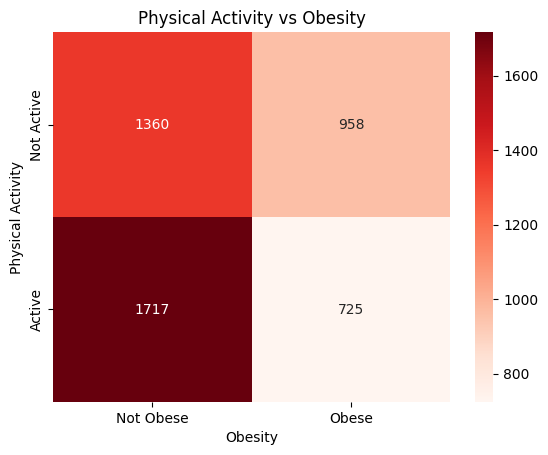

In [66]:

crosstab = pd.crosstab(df['PhysActive'], df['new_bmiBinary'])
sns.heatmap(crosstab, annot=True,fmt='d', cmap='Reds', xticklabels=['Not Obese','Obese'],
            yticklabels=['Not Active','Active'])
plt.title('Physical Activity vs Obesity')
plt.xlabel('Obesity')
plt.ylabel('Physical Activity')
plt.show()


In [67]:
percentageSmoke = 100 * (len(df[df['Smoke100'] == 'Yes'])/len(df))
percentageSmoke


42.47899159663866

<Axes: xlabel='BMI_WHO', ylabel='count'>

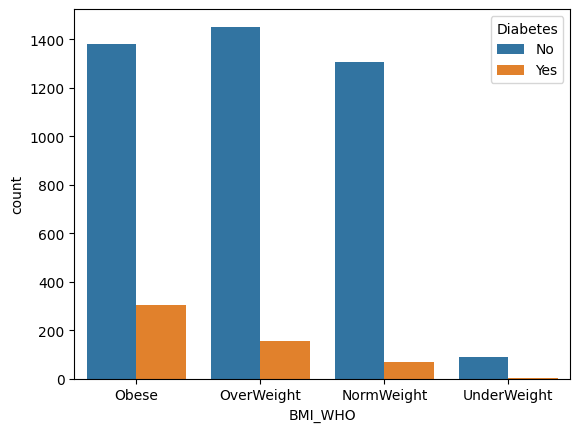

In [68]:

sns.countplot(x='BMI_WHO', hue='Diabetes',data=df)